<a href="https://colab.research.google.com/github/ha0-922/VLA/blob/main/SmolVLA_Inference.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# 🤖 SmolVLA Inference 데모

## 모델 소개: SmolVLA
- **SmolVLA** (Small Vision-Language-Action Model)는 HuggingFace가 2025년 공개한 소형 VLA 모델이에요
- VLA = **Vision(이미지) + Language(언어 명령) + Action(로봇 동작)** 을 하나의 모델로 처리
- 파라미터 수: **450M** (GPT 계열 대비 매우 작음 → 코랩 T4에서도 실행 가능)
- 내부 구조: SmolVLM2 (비전-언어 백본) + Action Expert (행동 예측 헤드)
- 학습 데이터: HuggingFace LeRobot 플랫폼의 커뮤니티 로봇 데이터셋

## 전체 흐름
```
카메라 이미지 ─┐
               ├──▶ SmolVLA ──▶ 로봇 관절 action (6차원 벡터)
언어 명령    ─┘
```


In [1]:
# LeRobot: HuggingFace의 로보틱스 라이브러리 (모델, 데이터셋, 정책 포함)
# num2words: SmolVLA 내부 언어 처리기에 필요한 의존성
!pip install lerobot num2words -q

  Preparing metadata (setup.py) ... done
  Installing build dependencies ... done
  Getting requirements to build wheel ... done
  Preparing metadata (pyproject.toml) ... done
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.1/1.1 MB 33.6 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 71.8/71.8 kB 8.7 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 163.5/163.5 kB 20.0 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 39.9/39.9 MB 25.9 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 92.0/92.0 kB 11.5 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 4.1/4.1 MB 135.7 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 54.0/54.0 MB 20.2 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 66.5/66.5 kB 5.2 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 91.7/91.7 kB 7.8 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 90.6/90.6 kB 7.9 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━

## Step 1. SmolVLA 모델 로드
- 출처: HuggingFace Hub `lerobot/smolvla_base`
- SmolVLM2-500M-Video-Instruct (비전-언어 백본) + Action Expert 두 파트로 구성
- 총 모델 크기: 약 3GB (백본 2GB + 액션 헤드 1GB)

In [2]:
from lerobot.policies.smolvla.modeling_smolvla import SmolVLAPolicy
import torch

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print("디바이스:", device)

policy = SmolVLAPolicy.from_pretrained("lerobot/smolvla_base")
policy = policy.to(device)
policy.eval()
print("Loaded SmolVLA")

디바이스: cuda


/usr/local/lib/python3.12/dist-packages/huggingface_hub/utils/_auth.py:94: UserWarning: 
The secret `HF_TOKEN` does not exist in your Colab secrets.
To authenticate with the Hugging Face Hub, create a token in your settings tab (https://huggingface.co/settings/tokens), set it as secret in your Google Colab and restart your session.
You will be able to reuse this secret in all of your notebooks.
Please note that authentication is recommended but still optional to access public models or datasets.
  warnings.warn(


config.json: 0.00B [00:00, ?B/s]

Loading  HuggingFaceTB/SmolVLM2-500M-Video-Instruct weights ...


config.json: 0.00B [00:00, ?B/s]

...

added_tokens.json: 0.00B [00:00, ?B/s]

special_tokens_map.json:   0%|          | 0.00/868 [00:00<?, ?B/s]

Reducing the number of VLM layers to 16 ...


model.safetensors:   0%|          | 0.00/907M [00:00<?, ?B/s]

Loaded SmolVLA


## Step 2. 데이터셋 로드
- 출처: HuggingFace Hub `lerobot/aloha_sim_insertion_scripted`
- ALOHA 로봇 시뮬레이터에서 수집한 데이터셋
- 태스크: **"Insert the peg into the socket"** (페그를 소켓에 꽂기)
- 각 샘플 구성:
  - `observation.images.top`: 위쪽 카메라 이미지 (3 × H × W)
  - `observation.state`: 로봇 현재 관절 상태 (6차원)
  - `action`: 정답 행동 레이블 (6차원)
  - `task`: 언어 명령 문자열

In [3]:
from lerobot.datasets.lerobot_dataset import LeRobotDataset

dataset = LeRobotDataset("lerobot/aloha_sim_insertion_scripted")
print("Finished loading data")
print("Dataset size:", len(dataset))

Fetching 4 files:   0%|          | 0/4 [00:00<?, ?it/s]

Fetching 10 files:   0%|          | 0/10 [00:00<?, ?it/s]

Finished loading data
Dataset size: 20000


## Step 3. 추론 (Inference)
### 처리 단계:
1. **이미지 전처리**: 카메라 이미지를 텐서로 변환 → 모델 입력 형식에 맞게 정규화
2. **언어 토크나이징**: "Insert the peg into the socket" 문장을 토큰 ID 시퀀스로 변환
3. **SmolVLA 추론**:
   - 비전 백본이 이미지에서 시각적 특징 추출
   - 언어 인코더가 명령을 임베딩으로 변환
   - Action Expert가 두 정보를 융합해 다음 행동 예측
4. **출력**: 로봇 관절 6개의 이동값 (action vector)


In [4]:
from transformers import AutoProcessor

# SmolVLA가 내부적으로 사용하는 언어 프로세서 로드
processor = AutoProcessor.from_pretrained("HuggingFaceTB/SmolVLM2-500M-Video-Instruct")

sample = dataset[0]
task = sample["task"]
print("언어 명령:", task)

# 언어 명령 토크나이징 (텍스트 → 숫자 시퀀스)
tokens = processor.tokenizer(
    task,
    return_tensors="pt",
    padding="max_length",
    max_length=64,
    truncation=True
)

# 이미지 & 상태 준비
image_input = sample["observation.images.top"].unsqueeze(0).to(device)
state_input = sample["observation.state"].unsqueeze(0).to(device)

# SmolVLA는 camera1/2/3 키 이름을 기대하므로 동일 이미지로 채움
batch = {
    "observation.images.camera1": image_input,
    "observation.images.camera2": image_input,
    "observation.images.camera3": image_input,
    "observation.state": state_input,
    "task": [task],
    "observation.language.tokens": tokens["input_ids"].to(device),
    "observation.language.attention_mask": tokens["attention_mask"].bool().to(device),
}

# 추론
with torch.no_grad():
    action = policy.select_action(batch)

print("Inference complete")
print("언어 명령:", task)
print("action shape:", action.shape)  # (1, 6) = 배치 1개, 관절 6개
print("action:", action)

언어 명령: Insert the peg into the socket.
Inference complete
언어 명령: Insert the peg into the socket.
action shape: torch.Size([1, 6])
action: tensor([[-0.2292, -1.1048,  1.1181,  0.2656, -0.2234, -0.3243]],
       device='cuda:0')


## Step 4. 연속 추론 & 시각화
- 20개 프레임에 걸쳐 연속으로 추론
- 각 프레임마다 SmolVLA가 이미지를 보고 언어 명령을 참고해서 action을 예측
- 관절 6개의 값이 시간에 따라 어떻게 변하는지 그래프로 확인
- **부드럽게 변하면** 모델이 일관성 있는 동작을 계획하고 있다는 의미

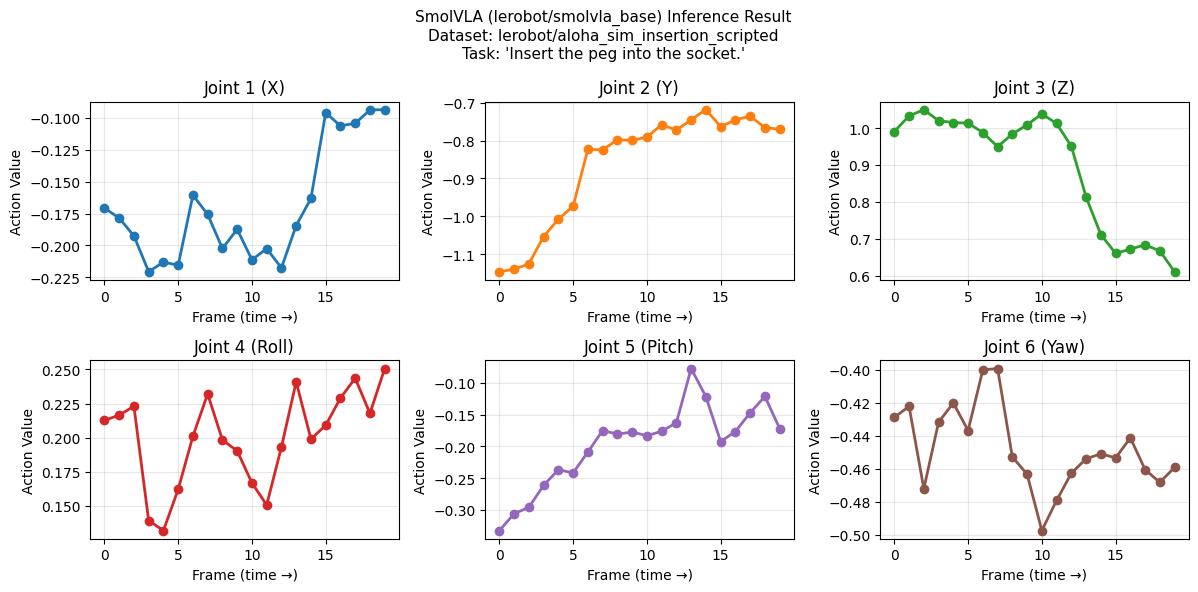

✅ 'smolvla_actions.png' successfully generated.


In [6]:
import matplotlib.pyplot as plt
import numpy as np

actions = []
n_frames = 20

policy.reset()

for i in range(n_frames):
    sample = dataset[i]
    task = sample["task"]

    tokens = processor.tokenizer(
        task,
        return_tensors="pt",
        padding="max_length",
        max_length=64,
        truncation=True
    )

    image_input = sample["observation.images.top"].unsqueeze(0).to(device)
    state_input = sample["observation.state"].unsqueeze(0).to(device)

    batch = {
        "observation.images.camera1": image_input,
        "observation.images.camera2": image_input,
        "observation.images.camera3": image_input,
        "observation.state": state_input,
        "task": [task],
        "observation.language.tokens": tokens["input_ids"].to(device),
        "observation.language.attention_mask": tokens["attention_mask"].bool().to(device),
    }

    with torch.no_grad():
        action = policy.select_action(batch)

    actions.append(action.squeeze(0).cpu().numpy())

actions = np.array(actions)  # (20, 6)

# 시각화
fig, axes = plt.subplots(2, 3, figsize=(12, 6))
fig.suptitle(
    f"SmolVLA (lerobot/smolvla_base) Inference Result\n"
    f"Dataset: lerobot/aloha_sim_insertion_scripted\n"
    f"Task: '{task}'",
    fontsize=11
)

joint_names = ["Joint 1 (X)", "Joint 2 (Y)", "Joint 3 (Z)",
               "Joint 4 (Roll)", "Joint 5 (Pitch)", "Joint 6 (Yaw)"]

for i, ax in enumerate(axes.flat):
    ax.plot(actions[:, i], marker='o', color=f"C{i}", linewidth=2)
    ax.set_title(joint_names[i])
    ax.set_xlabel("Frame (time →)")
    ax.set_ylabel("Action Value")
    ax.grid(True, alpha=0.3)

plt.tight_layout()
plt.savefig("smolvla_actions.png", dpi=100)
plt.show()
print("✅ 'smolvla_actions.png' successfully generated.")